# Rental RAG Robustness Evaluation

This notebook evaluates how consistently the final V2 RAG system performs when the same rental-rights question is asked in different ways.

The robustness test collection contains:

- 15 original questions
- 4 wording variants for each original question
- 75 questions in total

The RAG setup remains fixed:

- 32-chunk rental knowledge base
- BM25 retrieval
- `top_k = 5`
- `llama3.2:3b`
- final V2 grounded generation prompt

The only thing being changed is the wording of the user question. This allows us to test whether differences in grammar, spelling, sentence structure or conversational wording affect retrieval and answer quality.

## 1. Setup and Load Data

Load the fixed knowledge base and the expanded robustness test collection created in the previous notebook.

In [1]:
from pathlib import Path

import json
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 120)


# Locate project data folder

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Could not locate data/processed folder")

DATA_DIR = PROJECT_DIR / "data" / "processed"
EVAL_DIR = PROJECT_DIR / "data" / "evaluation"

EVAL_DIR.mkdir(parents=True, exist_ok=True)


# Load fixed knowledge base

kb_path = DATA_DIR / "rental_kb_chunks.jsonl"

kb_df = pd.read_json(
    kb_path,
    lines=True
)


# Load robustness test collection

test_path = (
    DATA_DIR
    / "rental_test_collection_robustness.jsonl"
)

robustness_df = pd.read_json(
    test_path,
    lines=True
)


print("Knowledge-base chunks:", len(kb_df))
print("Robustness questions:", len(robustness_df))
print(
    "Base questions:",
    robustness_df["base_question_id"].nunique()
)

print("\nQuestion types:")
print(
    robustness_df["question_type"]
    .value_counts()
)

print("\nVariant types:")
print(
    robustness_df["variant_type"]
    .value_counts()
)

Knowledge-base chunks: 32
Robustness questions: 75
Base questions: 15

Question types:
question_type
Known        40
Inferred     20
Out-of-KB    15
Name: count, dtype: int64

Variant types:
variant_type
Original                 15
Conversational           15
Short / informal         15
Grammar / spelling       15
Alternative structure    15
Name: count, dtype: int64


In [2]:
display(
    robustness_df[
        [
            "question_id",
            "base_question_id",
            "variant_type",
            "question",
            "question_type"
        ]
    ].head(10)
)

,question_id,base_question_id,variant_type,question,question_type
0,K01,K01,Original,Can a rental provider ask me about disputes with a previous landlord when I apply?,Known
1,K02,K02,Original,Can a rental provider accept an offer above the advertised rent?,Known
2,K03,K03,Original,Does a Victorian rental property need to have a fixed heater?,Known
3,K04,K04,Original,How long do I have to return my completed condition report after moving in?,Known
4,K05,K05,Original,How much rent can I be asked to pay in advance?,Known
5,K06,K06,Original,How much notice must I receive before my rent is increased?,Known
6,K07,K07,Original,Is a broken toilet considered an urgent repair?,Known
7,K08,K08,Original,What happens if my rental provider wants to refuse my request to keep a pet?,Known
8,I01,I01,Original,"My rental has no working fixed heater. Is this considered an urgent repair, and what can I do if the rental provider...",Inferred
9,I02,I02,Original,My rent is being increased and I think the new amount is too high. How much notice should I receive and what can I d...,Inferred


## 2. Load the Final V2 Retrieval Pipeline

Reuse the same BM25 retrieval setup used in the V2 evaluation.

Keeping the retriever and `top_k = 5` unchanged means any differences in retrieval performance should come from changes in how the same question is worded rather than from changes to the RAG pipeline.

In [3]:
import re

from rank_bm25 import BM25Okapi


# Keep the same retrieval configuration as V2
TOP_K = 5


def tokenize(text):
    return re.findall(
        r"\b\w+\b",
        text.lower()
    )


# Build BM25 index over the fixed 32-chunk KB
tokenized_corpus = (
    kb_df["text"]
    .apply(tokenize)
    .tolist()
)

bm25 = BM25Okapi(
    tokenized_corpus
)


def retrieve_bm25(question, top_k=TOP_K):
    query_tokens = tokenize(question)

    scores = bm25.get_scores(
        query_tokens
    )

    results = kb_df.copy()
    results["bm25_score"] = scores

    return (
        results
        .sort_values(
            "bm25_score",
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )


print("BM25 retriever ready")
print(f"Knowledge-base chunks: {len(kb_df)}")
print(f"Top-k: {TOP_K}")

BM25 retriever ready
Knowledge-base chunks: 32
Top-k: 5


In [4]:
# Quick retrieval check using the original K07 question

test_question = robustness_df.loc[
    robustness_df["question_id"] == "K07",
    "question"
].iloc[0]

test_results = retrieve_bm25(
    test_question
)

print("Question:")
print(test_question)

display(
    test_results[
        [
            "chunk_id",
            "document_name",
            "page",
            "bm25_score"
        ]
    ]
)

Question:
Is a broken toilet considered an urgent repair?


,chunk_id,document_name,page,bm25_score
0,RG_P24,Renters Guide,24,13.688134
1,RG_P25,Renters Guide,25,8.142652
2,RG_P26,Renters Guide,26,7.035357
3,RG_P15,Renters Guide,15,6.022584
4,MS_P01,Rental Minimum Standards Checklist,1,5.013737


## 3. Run Retrieval Across the Robustness Test Set

Run BM25 retrieval for all 75 questions and calculate the same retrieval metrics used in the original V2 evaluation.

For Known and Inferred questions:

- **Recall@5** measures how many of the expected relevant chunks were retrieved
- **MRR@5** measures how highly the first relevant chunk was ranked
- **NDCG@5** measures the overall ranking quality of relevant chunks

Out-of-KB questions are still passed through retrieval, but are not assigned retrieval relevance scores because they have no labelled relevant chunks.

In [5]:
import math


def evaluate_retrieval(row, top_k=TOP_K):
    results = retrieve_bm25(
        row["question"],
        top_k
    )

    retrieved_ids = (
        results["chunk_id"]
        .tolist()
    )

    retrieved_scores = (
        results["bm25_score"]
        .tolist()
    )

    retrieved_contexts = (
        results["text"]
        .tolist()
    )

    relevant_ids = set(
        row["relevant_chunk_ids"]
    )

    # Out-of-KB questions have no relevant chunks
    if not relevant_ids:
        return pd.Series({
            "retrieved_chunk_ids": retrieved_ids,
            "retrieved_scores": retrieved_scores,
            "retrieved_contexts": retrieved_contexts,
            "first_relevant_rank": np.nan,
            "recall_at_k": np.nan,
            "mrr_at_k": np.nan,
            "ndcg_at_k": np.nan
        })

    matched = [
        chunk_id
        for chunk_id in retrieved_ids
        if chunk_id in relevant_ids
    ]

    # Recall@k
    recall = (
        len(matched)
        / len(relevant_ids)
    )

    # Rank of first relevant result
    first_rank = next(
        (
            rank
            for rank, chunk_id in enumerate(
                retrieved_ids,
                start=1
            )
            if chunk_id in relevant_ids
        ),
        None
    )

    # MRR@k
    mrr = (
        1 / first_rank
        if first_rank
        else 0
    )

    # NDCG@k
    dcg = sum(
        1 / math.log2(rank + 1)
        for rank, chunk_id in enumerate(
            retrieved_ids,
            start=1
        )
        if chunk_id in relevant_ids
    )

    ideal_relevant = min(
        len(relevant_ids),
        top_k
    )

    idcg = sum(
        1 / math.log2(rank + 1)
        for rank in range(
            1,
            ideal_relevant + 1
        )
    )

    ndcg = (
        dcg / idcg
        if idcg
        else 0
    )

    return pd.Series({
        "retrieved_chunk_ids": retrieved_ids,
        "retrieved_scores": retrieved_scores,
        "retrieved_contexts": retrieved_contexts,
        "first_relevant_rank": first_rank,
        "recall_at_k": recall,
        "mrr_at_k": mrr,
        "ndcg_at_k": ndcg
    })


# Run retrieval evaluation across all 75 questions
retrieval_results = (
    robustness_df
    .apply(
        evaluate_retrieval,
        axis=1
    )
)

results_df = pd.concat(
    [
        robustness_df.copy(),
        retrieval_results
    ],
    axis=1
)


print(
    "Questions evaluated:",
    len(results_df)
)

display(
    results_df[
        [
            "question_id",
            "base_question_id",
            "variant_type",
            "question_type",
            "retrieved_chunk_ids",
            "first_relevant_rank",
            "recall_at_k",
            "mrr_at_k",
            "ndcg_at_k"
        ]
    ]
)

Questions evaluated: 75


,question_id,base_question_id,variant_type,question_type,retrieved_chunk_ids,first_relevant_rank,recall_at_k,mrr_at_k,ndcg_at_k
0,K01,K01,Original,Known,"[RG_P35, RG_P38, RG_P04, RG_P23, RG_P07]",5.0,1.0,0.2,0.386853
1,K02,K02,Original,Known,"[RG_P08, RG_P21, MS_P01, RG_P12, RG_P13]",1.0,1.0,1.0,1.000000
2,K03,K03,Original,Known,"[RG_P13, MS_P01, RG_P39, RG_P17, RG_P04]",1.0,1.0,1.0,1.000000
3,K04,K04,Original,Known,"[RG_P23, RG_P17, RG_P19, RG_P34, RG_P36]",2.0,1.0,0.5,0.693426
4,K05,K05,Original,Known,"[RG_P21, RG_P22, RG_P17, RG_P23, RG_P08]",1.0,1.0,1.0,1.000000
...,...,...,...,...,...,...,...,...,...
70,O02_V4,O02,Alternative structure,Out-of-KB,"[RG_P23, RG_P29, RG_P21, RG_P18, RG_P22]",NaN,NaN,NaN,NaN
71,O03_V1,O03,Conversational,Out-of-KB,"[RG_P23, RG_P15, RG_P04, RG_P26, RG_P08]",NaN,NaN,NaN,NaN
72,O03_V2,O03,Short / informal,Out-of-KB,"[RG_P23, RG_P04, RG_P26, RG_P14, MS_P02]",NaN,NaN,NaN,NaN
73,O03_V3,O03,Grammar / spelling,Out-of-KB,"[RG_P23, RG_P15, RG_P36, RG_P33, RG_P08]",NaN,NaN,NaN,NaN


In [6]:
# Overall retrieval performance for answerable questions

supported_results = results_df[
    results_df["question_type"]
    != "Out-of-KB"
]

retrieval_summary = pd.DataFrame({
    "metric": [
        "Recall@5",
        "MRR@5",
        "NDCG@5"
    ],
    "score": [
        supported_results[
            "recall_at_k"
        ].mean(),

        supported_results[
            "mrr_at_k"
        ].mean(),

        supported_results[
            "ndcg_at_k"
        ].mean()
    ]
})

display(
    retrieval_summary
    .round(3)
)

,metric,score
0,Recall@5,0.932
1,MRR@5,0.735
2,NDCG@5,0.771


## 4. Retrieval Robustness by Question Wording

Compare retrieval performance across the five ways each information need is expressed.

This helps identify whether conversational wording, shorter questions, spelling or grammar errors, or alternative sentence structures make it harder for BM25 to retrieve the expected evidence.

Only Known and Inferred questions are included because Out-of-KB questions do not have labelled relevant chunks.

In [7]:
# Check that the original questions reproduce the V2 retrieval results

original_retrieval = (
    supported_results[
        supported_results["variant_type"] == "Original"
    ][
        [
            "recall_at_k",
            "mrr_at_k",
            "ndcg_at_k"
        ]
    ]
    .mean()
)

print("Original-question retrieval:")
print(
    original_retrieval
    .round(3)
)

Original-question retrieval:
recall_at_k    0.979
mrr_at_k       0.808
ndcg_at_k      0.831
dtype: float64


In [8]:
# Compare retrieval performance by wording type

variant_order = [
    "Original",
    "Conversational",
    "Short / informal",
    "Grammar / spelling",
    "Alternative structure"
]

retrieval_by_variant = (
    supported_results
    .groupby("variant_type")
    .agg(
        questions=("question_id", "count"),
        recall_at_5=("recall_at_k", "mean"),
        mrr_at_5=("mrr_at_k", "mean"),
        ndcg_at_5=("ndcg_at_k", "mean"),
        full_recall_rate=(
            "recall_at_k",
            lambda x: (x == 1).mean()
        )
    )
    .reindex(variant_order)
    .reset_index()
)


# Difference from the original wording
original_row = retrieval_by_variant[
    retrieval_by_variant["variant_type"] == "Original"
].iloc[0]

retrieval_by_variant["recall_change"] = (
    retrieval_by_variant["recall_at_5"]
    - original_row["recall_at_5"]
)

retrieval_by_variant["mrr_change"] = (
    retrieval_by_variant["mrr_at_5"]
    - original_row["mrr_at_5"]
)

retrieval_by_variant["ndcg_change"] = (
    retrieval_by_variant["ndcg_at_5"]
    - original_row["ndcg_at_5"]
)


display(
    retrieval_by_variant
    .round(3)
)

,variant_type,questions,recall_at_5,mrr_at_5,ndcg_at_5,full_recall_rate,recall_change,mrr_change,ndcg_change
0,Original,12,0.979,0.808,0.831,0.917,0.000,0.000,0.000
1,Conversational,12,0.910,0.590,0.652,0.750,-0.069,-0.218,-0.180
2,Short / informal,12,0.951,0.732,0.779,0.833,-0.028,-0.076,-0.053
3,Grammar / spelling,12,0.868,0.819,0.796,0.667,-0.111,0.011,-0.035
4,Alternative structure,12,0.951,0.725,0.795,0.833,-0.028,-0.083,-0.036


## 5. Retrieval Robustness by Base Question

Group the five versions of each information need together to identify which rental-rights questions are most sensitive to changes in wording.

For each Known and Inferred base question, calculate average retrieval performance across the original question and its four variants, along with how many versions retrieved all expected evidence.

In [9]:
# Compare retrieval robustness across each base question

retrieval_by_question = (
    supported_results
    .groupby(
        [
            "base_question_id",
            "question_type"
        ]
    )
    .agg(
        question_versions=("question_id", "count"),
        mean_recall_at_5=("recall_at_k", "mean"),
        mean_mrr_at_5=("mrr_at_k", "mean"),
        mean_ndcg_at_5=("ndcg_at_k", "mean"),
        minimum_recall=("recall_at_k", "min"),
        full_recall_versions=(
            "recall_at_k",
            lambda x: (x == 1).sum()
        )
    )
    .reset_index()
)

display(
    retrieval_by_question
    .round(3)
)

,base_question_id,question_type,question_versions,mean_recall_at_5,mean_mrr_at_5,mean_ndcg_at_5,minimum_recall,full_recall_versions
0,I01,Inferred,5,0.750,0.900,0.730,0.750,0
1,I02,Inferred,5,1.000,1.000,1.000,1.000,5
2,I03,Inferred,5,0.733,0.567,0.570,0.667,1
3,I04,Inferred,5,0.800,0.450,0.518,0.500,3
4,K01,Known,5,1.000,0.640,0.730,1.000,5
5,K02,Known,5,1.000,0.750,0.812,1.000,5
6,K03,Known,5,1.000,1.000,1.000,1.000,5
7,K04,Known,5,0.900,0.417,0.569,0.500,4
8,K05,Known,5,1.000,0.690,0.764,1.000,5
9,K06,Known,5,1.000,0.800,0.852,1.000,5


In [10]:
# Show wording versions where BM25 missed expected evidence

retrieval_failures = (
    supported_results[
        supported_results["recall_at_k"] < 1
    ][
        [
            "question_id",
            "base_question_id",
            "variant_type",
            "question",
            "relevant_chunk_ids",
            "retrieved_chunk_ids",
            "recall_at_k",
            "first_relevant_rank"
        ]
    ]
    .sort_values(
        [
            "base_question_id",
            "variant_type"
        ]
    )
)

print(
    "Question versions with incomplete retrieval:",
    len(retrieval_failures)
)

display(retrieval_failures)

Question versions with incomplete retrieval: 12


,question_id,base_question_id,variant_type,question,relevant_chunk_ids,retrieved_chunk_ids,recall_at_k,first_relevant_rank
50,I01_V4,I01,Alternative structure,What options do I have if my rental has no working fixed heater and the rental provider does not respond to my repai...,"[RG_P13, MS_P01, RG_P24, RG_P25]","[RG_P23, RG_P25, MS_P01, RG_P13, RG_P26]",0.750000,2.0
47,I01_V1,I01,Conversational,"The fixed heater in my rental doesn't work. Is that urgent, and what can I do if the landlord doesn't organise a rep...","[RG_P13, MS_P01, RG_P24, RG_P25]","[RG_P25, RG_P22, RG_P24, RG_P26, MS_P01]",0.750000,1.0
49,I01_V3,I01,Grammar / spelling,My fixed heater isnt working is this urgent and what do i do if the landlord doesnt respond?,"[RG_P13, MS_P01, RG_P24, RG_P25]","[RG_P25, RG_P26, MS_P01, RG_P23, RG_P13]",0.750000,1.0
8,I01,I01,Original,"My rental has no working fixed heater. Is this considered an urgent repair, and what can I do if the rental provider...","[RG_P13, MS_P01, RG_P24, RG_P25]","[RG_P25, RG_P26, MS_P01, RG_P23, RG_P13]",0.750000,1.0
48,I01_V2,I01,Short / informal,No working heater. Is it urgent and what can I do if they don't fix it?,"[RG_P13, MS_P01, RG_P24, RG_P25]","[RG_P24, RG_P25, MS_P01, RG_P26, RG_P22]",0.750000,1.0
58,I03_V4,I03,Alternative structure,What information could help prove that damage being claimed against my bond existed before I moved in?,"[RG_P17, RG_P34, RG_P35]","[RG_P23, RG_P34, RG_P35, RG_P18, RG_P07]",0.666667,2.0
55,I03_V1,I03,Conversational,My landlord is trying to take money from my bond for damage that was already there. What can I use to show it wasn't...,"[RG_P17, RG_P34, RG_P35]","[RG_P23, RG_P17, RG_P26, RG_P35, RG_P08]",0.666667,2.0
57,I03_V3,I03,Grammar / spelling,My landlord wants my bond for damage that was already there what evidence can i use to dispute it?,"[RG_P17, RG_P34, RG_P35]","[RG_P23, RG_P32, RG_P35, RG_P26, RG_P34]",0.666667,3.0
56,I03_V2,I03,Short / informal,They're claiming my bond for old damage. What can I use to dispute it?,"[RG_P17, RG_P34, RG_P35]","[RG_P23, RG_P35, RG_P24, RG_P17, RG_P22]",0.666667,2.0
59,I04_V1,I04,Conversational,"Can my landlord evict me because I've used my rental rights, and what do they normally have to do to end my tenancy?","[RG_P32, RG_P33]","[RG_P23, RG_P26, RG_P25, RG_P33, RG_P34]",0.500000,4.0


## 6. Generate Answers Using the Final V2 Prompt

Pass the retrieved top-5 chunks for each question to the final V2 generation pipeline.

The retrieval method, model, context size and generation prompt remain fixed. This means differences between answers can be compared against changes in the wording of the original question.

The V2 prompt is designed to keep answers grounded in the retrieved evidence, use supporting chunk citations and abstain when the retrieved context does not contain enough information.

In [11]:
import requests


# Final V2 generation configuration
OLLAMA_MODEL = "llama3.2:3b"
OLLAMA_URL = "http://localhost:11434/api/generate"


def build_context(row):
    context_parts = []

    for chunk_id, text in zip(
        row["retrieved_chunk_ids"],
        row["retrieved_contexts"]
    ):
        chunk = kb_df.loc[
            kb_df["chunk_id"] == chunk_id
        ].iloc[0]

        context_parts.append(
            f"[{chunk_id}] "
            f"{chunk['document_name']} - Page {chunk['page']}\n"
            f"{text}"
        )

    return "\n\n---\n\n".join(context_parts)


def generate_answer(question, context):
    prompt = f"""
You are answering a question about Victorian rental rights using retrieved source material.

Read ALL of the retrieved chunks before answering. Relevant evidence may appear anywhere in the context.

Rules:
- Answer using only information explicitly supported by the retrieved context.
- If any retrieved chunk directly supports the answer, use that evidence and answer the question.
- Do not refuse simply because some retrieved chunks are irrelevant.
- Answer all parts of the question that are supported by the retrieved evidence.
- Do not invent, assume or infer rules that are not stated in the context.
- Cite the supporting chunk ID after each factual statement, for example [RG_P24].
- Only cite chunks that actually support the statement.
- If none of the retrieved chunks contain enough information to answer the question, respond exactly:
  "The retrieved information does not contain enough information to answer this question."

RETRIEVED CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""

    response = requests.post(
        OLLAMA_URL,
        json={
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0
            }
        }
    )

    response.raise_for_status()

    return response.json()["response"].strip()


# Build retrieved context for every question
results_df["retrieved_context"] = (
    results_df.apply(
        build_context,
        axis=1
    )
)

print("Generation pipeline ready")
print(f"Model: {OLLAMA_MODEL}")
print(f"Questions waiting: {len(results_df)}")

Generation pipeline ready
Model: llama3.2:3b
Questions waiting: 75


In [20]:
# Test the final V2 generation pipeline on K07

test_row = results_df[
    results_df["question_id"] == "K07"
].iloc[0]

test_answer = generate_answer(
    test_row["question"],
    test_row["retrieved_context"]
)

print("Question:")
print(test_row["question"])

print("\nGenerated answer:")
print(test_answer)

Question:
Is a broken toilet considered an urgent repair?

Generated answer:
The retrieved context does not provide enough information to answer this question directly.


### Generation Check

The final V2 pipeline was tested on K07 before running the full robustness evaluation.

Although the correct supporting evidence was retrieved at rank 1, the model abstained and stated that there was not enough information to answer the question. The retrieved `RG_P24` chunk explicitly lists a blocked or broken toilet system as an urgent repair.

This confirms that retrieval success does not always result in a correct generated answer and supports evaluating retrieval and generation separately.

In [16]:
import time

start_time = time.perf_counter()

second_test_answer = generate_answer(
    test_row["question"],
    test_row["retrieved_context"]
)

elapsed = time.perf_counter() - start_time

print(f"Generation time: {elapsed:.1f} seconds")

print("\nGenerated answer:")
print(second_test_answer)

Generation time: 73.4 seconds

Generated answer:
According to the retrieved context, specifically [RG_P24] Renters Guide - Page 24, a broken toilet is not explicitly listed as an urgent repair. However, it is mentioned that the toilet must be in good working order and connected to either a reticulated sewerage system, a wastewater treatment system, or another system approved by the local council.

It is also mentioned that the toilet must be in a separate room in the property, either by itself, or in an appropriate room like a bathroom or in a combined bathroom-laundry.

There is no explicit mention of a broken toilet as an urgent repair. Therefore, it cannot be concluded that a broken toilet is an urgent repair based on the retrieved context.


In [14]:
print(test_row["retrieved_context"])

[RG_P24] Renters Guide - Page 24
Problems with the property
Your rental provider must make sure the property is in good condition and fit to
live in. It doesn’t matter how much rent you are paying or how old the property is.
If there’s a problem with the property, you can ask your rental provider to fix it.
If they don’t, contact Consumer Affairs Victoria for information and advice.
Repairs
Repairs are either ‘urgent’ or ‘non-urgent’. Rental providers must make
urgent repairs immediately. Rental providers must make non-urgent repairs
within 14 days of getting a written request.
Urgent repairs
Anything on this list is legally defined as an urgent repair:
• burst water service
• blocked or broken toilet system
• serious roof leak
• gas leak
• dangerous electrical fault
• flooding or serious flood damage
• serious storm or fire damage
• an essential service or appliance for hot water, water, cooking, heating,
or laundering isn’t working
• the gas, electricity or water supply isn’t working

In [15]:
import subprocess

result = subprocess.run(
    ["ollama", "ps"],
    capture_output=True,
    text=True
)

print(result.stdout)

NAME           ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
llama3.2:3b    a80c4f17acd5    2.6 GB    100% CPU     4096       2 minutes from now    



In [ ]:
# checkpoint_path = (
#     EVAL_DIR
#     / "robustness_generation_checkpoint.jsonl"
# )

# if checkpoint_path.exists():
#     checkpoint_path.unlink()
#     print("Old checkpoint deleted")
# else:
#     print("No checkpoint found")

Old checkpoint deleted


In [12]:
# Generate answers with progress and checkpoint saving

from tqdm.auto import tqdm
import time

checkpoint_path = (
    EVAL_DIR
    / "robustness_generation_checkpoint.jsonl"
)

# Start from any existing checkpoint
if checkpoint_path.exists():

    checkpoint_df = pd.read_json(
        checkpoint_path,
        lines=True
    )

    completed_ids = set(
        checkpoint_df["question_id"]
    )

    print(
        f"Loaded {len(completed_ids)} completed answers"
    )

else:
    checkpoint_df = pd.DataFrame()
    completed_ids = set()

    print("Starting new generation run")


new_results = []

for _, row in tqdm(
    results_df.iterrows(),
    total=len(results_df)
):

    question_id = row["question_id"]

    # Skip questions already completed
    if question_id in completed_ids:
        continue

    start_time = time.perf_counter()

    answer = generate_answer(
        row["question"],
        row["retrieved_context"]
    )

    elapsed = (
        time.perf_counter()
        - start_time
    )

    new_results.append({
        "question_id": question_id,
        "generated_answer": answer,
        "generation_seconds": elapsed
    })

    # Save after every question
    current_results = pd.concat(
        [
            checkpoint_df,
            pd.DataFrame(new_results)
        ],
        ignore_index=True
    )

    current_results.to_json(
        checkpoint_path,
        orient="records",
        lines=True,
        force_ascii=False
    )


print("\nGeneration run complete")

generated_df = pd.read_json(
    checkpoint_path,
    lines=True
)

print(
    f"Answers completed: {len(generated_df)} / "
    f"{len(results_df)}"
)

print(
    f"Average generation time: "
    f"{generated_df['generation_seconds'].mean():.1f} seconds"
)

Loaded 75 completed answers


  0%|          | 0/75 [00:00<?, ?it/s]


Generation run complete
Answers completed: 75 / 75
Average generation time: 102.3 seconds


## 7. Merge Generated Answers

The completed V2 responses are merged back into the robustness evaluation results.

This combines each generated answer with its question metadata and retrieval results so retrieval and generation behaviour can be compared across the original questions and their wording variants.

In [13]:
# Load completed generation results
generated_df = pd.read_json(
    checkpoint_path,
    lines=True
)

# Remove existing generation columns if present
results_df = results_df.drop(
    columns=[
        "generated_answer",
        "generation_seconds"
    ],
    errors="ignore"
)

# Merge answers into the full evaluation results
results_df = results_df.merge(
    generated_df,
    on="question_id",
    how="left",
    validate="one_to_one"
)

# Basic checks
print(f"Total questions: {len(results_df)}")

print(
    "Generated answers:",
    results_df["generated_answer"].notna().sum()
)

print(
    "Missing answers:",
    results_df["generated_answer"].isna().sum()
)

print(
    "Duplicate question IDs:",
    results_df["question_id"].duplicated().sum()
)

print(
    f"Average generation time: "
    f"{results_df['generation_seconds'].mean():.1f} seconds"
)

Total questions: 75
Generated answers: 75
Missing answers: 0
Duplicate question IDs: 0
Average generation time: 102.3 seconds


## 8. Save Raw Robustness Results

The completed robustness run is saved before any additional evaluation labels or summary metrics are added.

This preserves the original questions, wording variants, retrieval results, generated answers and generation times from the final V2 system.

In [14]:
# Save the full raw robustness run

raw_results_path = (
    EVAL_DIR
    / "v2_robustness_raw_results.jsonl"
)

results_df.to_json(
    raw_results_path,
    orient="records",
    lines=True,
    force_ascii=False
)

print(f"Saved: {raw_results_path}")
print(f"Rows saved: {len(results_df)}")

Saved: /Users/seanrichards/Documents/University/DS Case Studies/Project/data/evaluation/v2_robustness_raw_results.jsonl
Rows saved: 75


## 9. Inspect Abstention Behaviour

The first generation-level robustness check looks at when the final V2 system decides that it does not have enough information to answer.

This is important because the test set contains both:
- answerable Known and Inferred questions, where abstaining is a failure
- Out-of-KB questions, where abstaining is the correct behaviour

Before calculating summary metrics, possible abstentions are identified and inspected so slightly different wording used by the language model is not missed.

In [38]:
# Identify possible abstention responses

abstention_patterns = [
    "not enough information",
    "does not contain enough information",
    "does not provide enough information",
    "does not contain information",
    "does not provide information",
    "no information about",
    "no information on",
    "cannot answer",
    "can't answer",
    "cannot be answered",
    "unable to answer",
    "cannot conclude",
    "cannot be concluded"
]

def possible_abstention(answer):
    answer_lower = str(answer).lower()

    return any(
        pattern in answer_lower
        for pattern in abstention_patterns
    )


results_df["possible_abstention"] = (
    results_df["generated_answer"]
    .apply(possible_abstention)
)

abstention_candidates = results_df[
    results_df["possible_abstention"]
][
    [
        "question_id",
        "base_question_id",
        "variant_type",
        "question_type",
        "question",
        "generated_answer"
    ]
]

print(
    f"Possible abstentions found: "
    f"{len(abstention_candidates)} / {len(results_df)}"
)

display(abstention_candidates)

Possible abstentions found: 26 / 75


,question_id,base_question_id,variant_type,question_type,question,generated_answer
6,K07,K07,Original,Known,Is a broken toilet considered an urgent repair?,The retrieved context does not provide information on whether a broken toilet is considered an urgent repair.
12,O01,O01,Original,Out-of-KB,Can I sublet my rental property to another person without my rental provider's permission?,The retrieved context does not contain enough information to answer this question.
13,O02,O02,Original,Out-of-KB,How much does it cost to make a rental application to VCAT?,The retrieved information does not contain enough information to answer this question.
14,O03,O03,Original,Out-of-KB,Can my rental provider install security cameras inside my rental property?,The retrieved context does not provide enough information to answer this question directly.
16,K01_V2,K01,Short / informal,Known,Can they ask about problems I had with a previous landlord?,The retrieved context does not contain enough information to answer this question.
19,K02_V1,K02,Conversational,Known,"If I offer more than the advertised rent, is the rental provider allowed to accept it?",The retrieved context does not contain enough information to answer this question.
20,K02_V2,K02,Short / informal,Known,Can a landlord take an offer above the listed rent?,The retrieved information does not contain enough information to answer this question.
21,K02_V3,K02,Grammar / spelling,Known,Can they accept more rent then what was advertised?,The retrieved context does not contain enough information to answer this question.
39,K07_V1,K07,Conversational,Known,My toilet has broken. Does that count as an urgent repair?,"According to [RG_P24], a toilet that is not connected to a sewage treatment plant, wastewater treatment system, or o..."
41,K07_V3,K07,Grammar / spelling,Known,My toilet is broke is this classed as a urgent repair?,"According to [RG_P24], a serious problem with a toilet is classified as an urgent repair. However, the retrieved con..."


In [39]:
# Print full possible-abstention responses for review

for _, row in abstention_candidates.iterrows():

    print("=" * 100)

    print(
        f"{row['question_id']} | "
        f"{row['question_type']} | "
        f"{row['variant_type']}"
    )

    print("\nQuestion:")
    print(row["question"])

    print("\nGenerated answer:")
    print(row["generated_answer"])

    print()

K07 | Known | Original

Question:
Is a broken toilet considered an urgent repair?

Generated answer:
The retrieved context does not provide information on whether a broken toilet is considered an urgent repair.

O01 | Out-of-KB | Original

Question:
Can I sublet my rental property to another person without my rental provider's permission?

Generated answer:
The retrieved context does not contain enough information to answer this question.

O02 | Out-of-KB | Original

Question:
How much does it cost to make a rental application to VCAT?

Generated answer:
The retrieved information does not contain enough information to answer this question.

O03 | Out-of-KB | Original

Question:
Can my rental provider install security cameras inside my rental property?

Generated answer:
The retrieved context does not provide enough information to answer this question directly.

K01_V2 | Known | Short / informal

Question:
Can they ask about problems I had with a previous landlord?

Generated answer:
Th

In [40]:
# Inspect newly detected answerable candidates

check_ids = [
    "I02_V3",
    "I03_V3"
]

for question_id in check_ids:

    row = results_df[
        results_df["question_id"] == question_id
    ].iloc[0]

    print("=" * 100)
    print(
        f"{row['question_id']} | "
        f"{row['question_type']} | "
        f"{row['variant_type']}"
    )

    print("\nQuestion:")
    print(row["question"])

    print("\nGenerated answer:")
    print(row["generated_answer"])

    print()

I02_V3 | Inferred | Grammar / spelling

Question:
My rents going up and i think its too high how much notice should they give and can i dispute it?

Generated answer:
According to [RG_P23], your rental provider must give you a Notice of rent increase at least 90 days before they are going to put the rent up. 

Additionally, you can ask Consumer Affairs Victoria to investigate if you believe the increased rent is too high, and you must contact them within 30 days of receiving a rent increase notice. You can use the Request for rental assessment form to ask for a rent assessment.

The retrieved context does not provide information on the specific notice period for disputing a rent increase.

I03_V3 | Inferred | Grammar / spelling

Question:
My landlord wants my bond for damage that was already there what evidence can i use to dispute it?

Generated answer:
According to [RG_P35], your rental provider can claim part or all of the bond for specific things, such as damage caused by you or yo

In [41]:
# Final abstention labels after manual review

results_df["is_abstention"] = (
    results_df["possible_abstention"]
)

# I02_V3 answers the main question despite its final disclaimer
results_df.loc[
    results_df["question_id"] == "I02_V3",
    "is_abstention"
] = False

print(
    "Final abstentions:",
    results_df["is_abstention"].sum(),
    "/",
    len(results_df)
)

Final abstentions: 25 / 75


## 10. Abstention and Effectiveness Metrics

The reviewed abstention candidates are now treated as genuine unanswered responses.

Effectiveness is measured using the overall unanswered rate, following the Walert-style evaluation approach. However, unanswered rate alone is not treated as a measure of quality because the test collection intentionally contains Out-of-KB questions.

The analysis therefore also measures:
- **Out-of-KB abstention accuracy** — how often the system correctly refuses unsupported questions.
- **False abstention rate** — how often it refuses a Known or Inferred question that should be answerable.
- **Answerable-question coverage** — how often it provides an answer for Known and Inferred questions.

In [42]:
# Calculate final abstention and effectiveness metrics

# Separate answerable and Out-of-KB questions
answerable_mask = (
    results_df["question_type"]
    .isin(["Known", "Inferred"])
)

oob_mask = (
    results_df["question_type"]
    == "Out-of-KB"
)


# Overall unanswered rate
unanswered_rate = (
    results_df["is_abstention"].mean()
)

# Correct Out-of-KB abstention
oob_abstention_accuracy = (
    results_df.loc[
        oob_mask,
        "is_abstention"
    ].mean()
)

# Incorrect abstention on answerable questions
false_abstention_rate = (
    results_df.loc[
        answerable_mask,
        "is_abstention"
    ].mean()
)

# Answerable questions receiving an answer
answerable_coverage = (
    1 - false_abstention_rate
)


print(
    f"Overall unanswered rate: "
    f"{unanswered_rate:.3f}"
)

print(
    f"Out-of-KB abstention accuracy: "
    f"{oob_abstention_accuracy:.3f}"
)

print(
    f"False abstention rate: "
    f"{false_abstention_rate:.3f}"
)

print(
    f"Answerable-question coverage: "
    f"{answerable_coverage:.3f}"
)

print("\nCounts")

print(
    "Total abstentions:",
    results_df["is_abstention"].sum(),
    "/",
    len(results_df)
)

print(
    "Correct Out-of-KB abstentions:",
    results_df.loc[
        oob_mask,
        "is_abstention"
    ].sum(),
    "/",
    oob_mask.sum()
)

print(
    "False abstentions:",
    results_df.loc[
        answerable_mask,
        "is_abstention"
    ].sum(),
    "/",
    answerable_mask.sum()
)

Overall unanswered rate: 0.333
Out-of-KB abstention accuracy: 1.000
False abstention rate: 0.167
Answerable-question coverage: 0.833

Counts
Total abstentions: 25 / 75
Correct Out-of-KB abstentions: 15 / 15
False abstentions: 10 / 60


## 11. Abstention Robustness by Wording Style

Abstention behaviour is compared across the original questions and the four wording variants.

For each wording style, the analysis measures:
- overall unanswered rate
- Out-of-KB abstention accuracy
- false abstention rate on Known and Inferred questions
- answerable-question coverage

This shows whether the system's decision to answer or abstain changes when the underlying question stays the same but the wording changes.

In [43]:
# Compare abstention behaviour by wording style

variant_order = [
    "Original",
    "Conversational",
    "Short / informal",
    "Grammar / spelling",
    "Alternative structure"
]

summary_rows = []

for variant in variant_order:

    subset = results_df[
        results_df["variant_type"] == variant
    ]

    answerable_subset = subset[
        subset["question_type"].isin(
            ["Known", "Inferred"]
        )
    ]

    oob_subset = subset[
        subset["question_type"] == "Out-of-KB"
    ]

    summary_rows.append({
        "variant_type": variant,
        "questions": len(subset),
        "unanswered_rate":
            subset["is_abstention"].mean(),
        "oob_abstention_accuracy":
            oob_subset["is_abstention"].mean(),
        "false_abstention_rate":
            answerable_subset["is_abstention"].mean(),
        "answerable_coverage":
            1 - answerable_subset["is_abstention"].mean()
    })


abstention_by_wording_df = pd.DataFrame(
    summary_rows
)

display(
    abstention_by_wording_df.round(3)
)

,variant_type,questions,unanswered_rate,oob_abstention_accuracy,false_abstention_rate,answerable_coverage
0,Original,15,0.267,1.0,0.083,0.917
1,Conversational,15,0.333,1.0,0.167,0.833
2,Short / informal,15,0.333,1.0,0.167,0.833
3,Grammar / spelling,15,0.400,1.0,0.250,0.750
4,Alternative structure,15,0.333,1.0,0.167,0.833


## 12. Abstention Robustness by Base Question

The previous results show that all four wording styles have similar overall abstention performance.

However, the same questions are not necessarily failing under each wording style. The analysis is therefore grouped by the original base question to identify which topics are most sensitive to rewording.

For Known and Inferred questions, the expected behaviour is to answer all five versions. For Out-of-KB questions, the expected behaviour is to abstain from all five versions.

In [44]:
# Expected abstention behaviour
results_df["expected_abstention"] = (
    results_df["question_type"] == "Out-of-KB"
)

# Was the answer/abstain decision correct?
results_df["abstention_decision_correct"] = (
    results_df["is_abstention"]
    == results_df["expected_abstention"]
)

# Summarise by underlying question
abstention_by_question_df = (
    results_df
    .groupby(
        ["base_question_id", "question_type"],
        as_index=False
    )
    .agg(
        versions=("question_id", "count"),
        abstentions=("is_abstention", "sum"),
        correct_decisions=(
            "abstention_decision_correct",
            "sum"
        )
    )
)

abstention_by_question_df[
    "decision_accuracy"
] = (
    abstention_by_question_df["correct_decisions"]
    / abstention_by_question_df["versions"]
)

display(
    abstention_by_question_df.round(3)
)

,base_question_id,question_type,versions,abstentions,correct_decisions,decision_accuracy
0,I01,Inferred,5,0,5,1.0
1,I02,Inferred,5,0,5,1.0
2,I03,Inferred,5,2,3,0.6
3,I04,Inferred,5,0,5,1.0
4,K01,Known,5,1,4,0.8
5,K02,Known,5,3,2,0.4
6,K03,Known,5,0,5,1.0
7,K04,Known,5,0,5,1.0
8,K05,Known,5,0,5,1.0
9,K06,Known,5,0,5,1.0


### Key Finding

The V2 system remained reliable at recognising unsupported questions, correctly abstaining on all 15 Out-of-KB versions.

The main robustness weakness was false abstention on questions that should have been answerable. Across the 60 Known and Inferred versions, 10 were incorrectly refused, giving a false abstention rate of 16.7%.

This behaviour also changed depending on wording. The original questions had 91.7% answerable coverage, while grammar and spelling variants dropped to 75.0%. K07 was the least stable question, with the correct answer/abstain decision in only 1 of 5 versions, followed by K02 at 2 of 5.

Overall, the results suggest that V2 is conservative when evidence may be missing, but this caution sometimes causes it to reject answerable questions when the wording changes.

In [45]:
# Show incorrect answer/abstain decisions

abstention_failures_df = results_df[
    ~results_df["abstention_decision_correct"]
][
    [
        "question_id",
        "base_question_id",
        "variant_type",
        "question_type",
        "question",
        "retrieved_chunk_ids",
        "generated_answer"
    ]
]

print(
    f"Incorrect abstention decisions: "
    f"{len(abstention_failures_df)} / {len(results_df)}"
)

display(abstention_failures_df)

Incorrect abstention decisions: 10 / 75


,question_id,base_question_id,variant_type,question_type,question,retrieved_chunk_ids,generated_answer
6,K07,K07,Original,Known,Is a broken toilet considered an urgent repair?,"[RG_P24, RG_P25, RG_P26, RG_P15, MS_P01]",The retrieved context does not provide information on whether a broken toilet is considered an urgent repair.
16,K01_V2,K01,Short / informal,Known,Can they ask about problems I had with a previous landlord?,"[RG_P07, RG_P23, RG_P35, RG_P24, RG_P26]",The retrieved context does not contain enough information to answer this question.
19,K02_V1,K02,Conversational,Known,"If I offer more than the advertised rent, is the rental provider allowed to accept it?","[RG_P21, RG_P08, RG_P23, RG_P12, RG_P22]",The retrieved context does not contain enough information to answer this question.
20,K02_V2,K02,Short / informal,Known,Can a landlord take an offer above the listed rent?,"[RG_P21, MS_P01, RG_P26, RG_P08, RG_P13]",The retrieved information does not contain enough information to answer this question.
21,K02_V3,K02,Grammar / spelling,Known,Can they accept more rent then what was advertised?,"[RG_P08, RG_P34, RG_P22, RG_P35, RG_P21]",The retrieved context does not contain enough information to answer this question.
39,K07_V1,K07,Conversational,Known,My toilet has broken. Does that count as an urgent repair?,"[RG_P24, RG_P26, RG_P25, RG_P23, RG_P15]","According to [RG_P24], a toilet that is not connected to a sewage treatment plant, wastewater treatment system, or o..."
41,K07_V3,K07,Grammar / spelling,Known,My toilet is broke is this classed as a urgent repair?,"[RG_P24, RG_P25, RG_P26, RG_P23, RG_P15]","According to [RG_P24], a serious problem with a toilet is classified as an urgent repair. However, the retrieved con..."
42,K07_V4,K07,Alternative structure,Known,"If the toilet in my rental stops working, is it treated as an urgent repair?","[RG_P24, RG_P25, RG_P26, MS_P02, MS_P01]","According to [MS_P02] Rental Minimum Standards Checklist - Page 2, the toilet must be in good working order and conn..."
57,I03_V3,I03,Grammar / spelling,Inferred,My landlord wants my bond for damage that was already there what evidence can i use to dispute it?,"[RG_P23, RG_P32, RG_P35, RG_P26, RG_P34]","According to [RG_P35], your rental provider can claim part or all of the bond for specific things, such as damage ca..."
58,I03_V4,I03,Alternative structure,Inferred,What information could help prove that damage being claimed against my bond existed before I moved in?,"[RG_P23, RG_P34, RG_P35, RG_P18, RG_P07]","According to [RG_P35] Renters Guide - Page 35, damage caused by you or your visitors (but not fair wear and tear) ca..."


In [46]:
# Final abstention labels after manual review

results_df["is_abstention"] = (
    results_df["possible_abstention"]
)

# I02_V3 answers the main question despite its final disclaimer
results_df.loc[
    results_df["question_id"] == "I02_V3",
    "is_abstention"
] = False

print(
    "Final abstentions:",
    results_df["is_abstention"].sum(),
    "/",
    len(results_df)
)

Final abstentions: 25 / 75


In [47]:
# Load the existing V1 vs V2 evaluation comparison

comparison_path = (
    EVAL_DIR
    / "v1_v2_summary_comparison.csv"
)

main_summary_df = pd.read_csv(
    comparison_path
)

# Clean column names for display
main_summary_df = main_summary_df.rename(
    columns={
        "evaluation_area": "Evaluation Area",
        "metric": "Metric",
        "v1": "V1",
        "v2": "V2",
        "v1_score": "V1",
        "v2_score": "V2",
        "change": "Change"
    }
)

# Convert numeric scores to percentages for display
main_summary_display = (
    main_summary_df.copy()
)

for col in ["V1", "V2", "Change"]:
    if col in main_summary_display.columns:
        main_summary_display[col] = (
            main_summary_display[col]
            .apply(
                lambda x:
                f"{x * 100:.1f}%"
                if pd.notna(x)
                else ""
            )
        )

display(
    main_summary_display
)

,Metric,V1,V2,Change
0,Recall@5,97.9%,97.9%,0.0%
1,MRR@5,80.8%,80.8%,0.0%
2,NDCG@5,83.1%,83.1%,0.0%
3,Answer correctness,80.0%,80.0%,0.0%
4,Mean question completeness,73.2%,59.4%,-13.8%
5,Gold-fact coverage,60.6%,51.5%,-9.1%
6,Claim-level faithfulness,80.0%,92.9%,12.9%
7,Unsupported claim rate,20.0%,7.1%,-12.9%
8,Citation presence,60.0%,73.3%,13.3%
9,Citations from retrieved context,100.0%,100.0%,0.0%


In [48]:
# Build final 75-question robustness summary

answerable_mask = (
    results_df["question_type"]
    .isin(["Known", "Inferred"])
)

oob_mask = (
    results_df["question_type"]
    == "Out-of-KB"
)

supported_results = (
    results_df[answerable_mask]
)

robustness_summary_df = pd.DataFrame({
    "Evaluation Area": [
        "Retrieval",
        "Retrieval",
        "Retrieval",
        "Retrieval",
        "Answer Behaviour",
        "Answer Behaviour",
        "Answer Behaviour",
        "Out-of-KB Behaviour"
    ],
    "Metric": [
        "Recall@5",
        "MRR@5",
        "NDCG@5",
        "Full relevant-evidence retrieval",
        "Overall unanswered rate",
        "Answerable-question coverage",
        "False abstention rate",
        "Out-of-KB abstention accuracy"
    ],
    "Result": [
        supported_results[
            "recall_at_k"
        ].mean(),

        supported_results[
            "mrr_at_k"
        ].mean(),

        supported_results[
            "ndcg_at_k"
        ].mean(),

        supported_results[
            "recall_at_k"
        ].eq(1).mean(),

        results_df[
            "is_abstention"
        ].mean(),

        1 - results_df.loc[
            answerable_mask,
            "is_abstention"
        ].mean(),

        results_df.loc[
            answerable_mask,
            "is_abstention"
        ].mean(),

        results_df.loc[
            oob_mask,
            "is_abstention"
        ].mean()
    ]
})

robustness_summary_display = (
    robustness_summary_df.copy()
)

robustness_summary_display[
    "Result"
] = (
    robustness_summary_display[
        "Result"
    ]
    .apply(
        lambda x: f"{x * 100:.1f}%"
    )
)

display(
    robustness_summary_display
)

,Evaluation Area,Metric,Result
0,Retrieval,Recall@5,93.2%
1,Retrieval,MRR@5,73.5%
2,Retrieval,NDCG@5,77.1%
3,Retrieval,Full relevant-evidence retrieval,80.0%
4,Answer Behaviour,Overall unanswered rate,33.3%
5,Answer Behaviour,Answerable-question coverage,83.3%
6,Answer Behaviour,False abstention rate,16.7%
7,Out-of-KB Behaviour,Out-of-KB abstention accuracy,100.0%


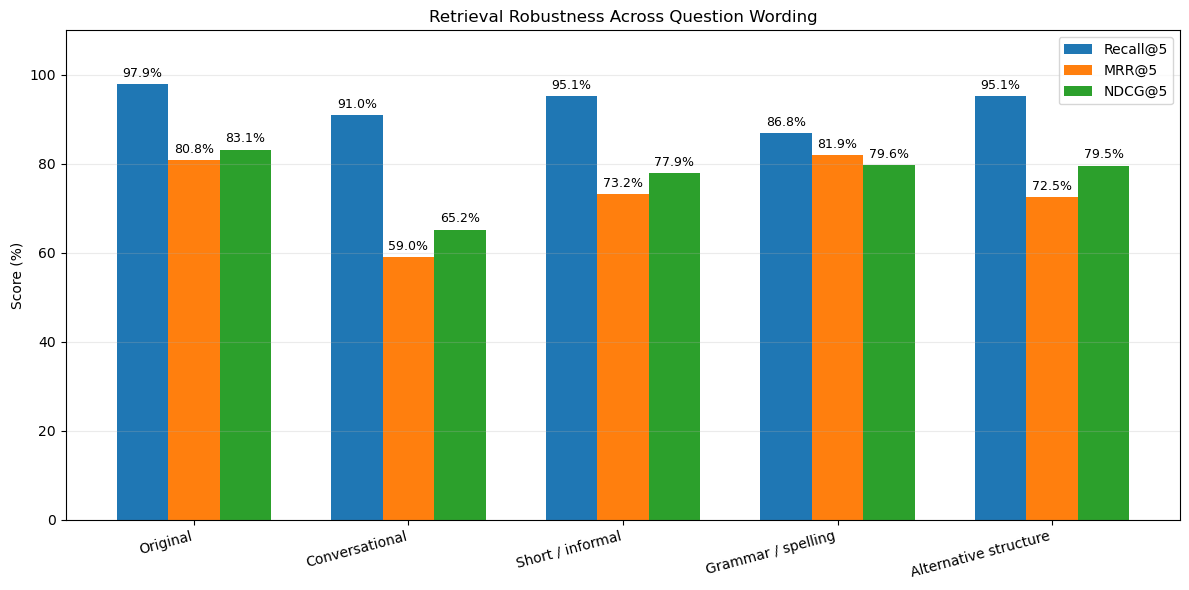

In [51]:
import matplotlib.pyplot as plt
import numpy as np

variant_order = [
    "Original",
    "Conversational",
    "Short / informal",
    "Grammar / spelling",
    "Alternative structure"
]

# Use only answerable questions for retrieval evaluation
retrieval_plot_df = (
    results_df[
        results_df["question_type"].isin(["Known", "Inferred"])
    ]
    .groupby("variant_type")
    .agg(
        Recall_at_5=("recall_at_k", "mean"),
        MRR_at_5=("mrr_at_k", "mean"),
        NDCG_at_5=("ndcg_at_k", "mean")
    )
    .reindex(variant_order)
    * 100
)

x = np.arange(len(retrieval_plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width,
    retrieval_plot_df["Recall_at_5"],
    width,
    label="Recall@5"
)

bars2 = ax.bar(
    x,
    retrieval_plot_df["MRR_at_5"],
    width,
    label="MRR@5"
)

bars3 = ax.bar(
    x + width,
    retrieval_plot_df["NDCG_at_5"],
    width,
    label="NDCG@5"
)

# Add labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title("Retrieval Robustness Across Question Wording")
ax.set_ylabel("Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(variant_order, rotation=15, ha="right")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

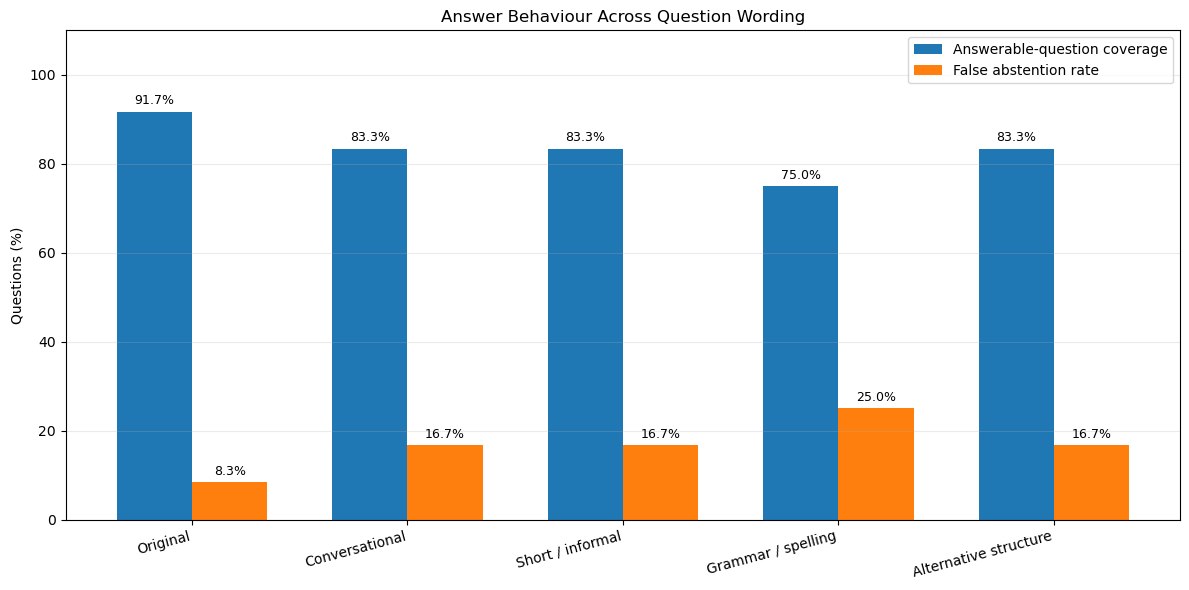

In [52]:
import matplotlib.pyplot as plt
import numpy as np

variant_order = [
    "Original",
    "Conversational",
    "Short / informal",
    "Grammar / spelling",
    "Alternative structure"
]

answerable_plot_df = (
    results_df[
        results_df["question_type"].isin(["Known", "Inferred"])
    ]
    .groupby("variant_type")
    .agg(
        False_abstention_rate=("is_abstention", "mean")
    )
    .reindex(variant_order)
)

answerable_plot_df["Answerable_coverage"] = (
    1 - answerable_plot_df["False_abstention_rate"]
)

answerable_plot_df = answerable_plot_df * 100

x = np.arange(len(answerable_plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width / 2,
    answerable_plot_df["Answerable_coverage"],
    width,
    label="Answerable-question coverage"
)

bars2 = ax.bar(
    x + width / 2,
    answerable_plot_df["False_abstention_rate"],
    width,
    label="False abstention rate"
)

# Add labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title("Answer Behaviour Across Question Wording")
ax.set_ylabel("Questions (%)")
ax.set_xticks(x)
ax.set_xticklabels(variant_order, rotation=15, ha="right")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

/var/folders/0v/6w7tpnxd2_91brcp_nw7nn380000gn/T/ipykernel_2951/2450664480.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


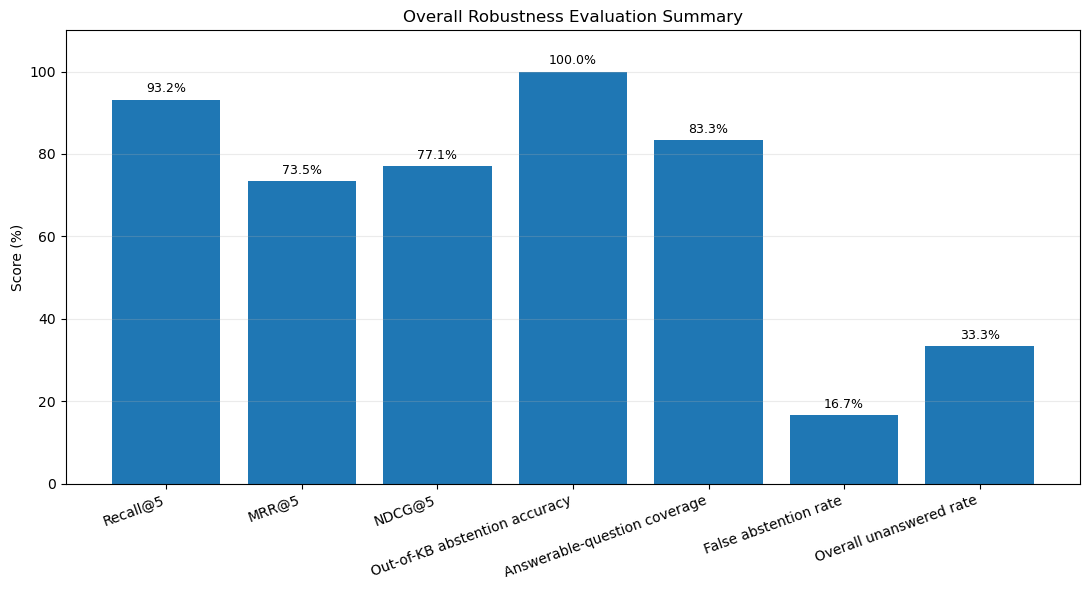

In [53]:
import matplotlib.pyplot as plt

overall_robustness_metrics = pd.DataFrame({
    "metric": [
        "Recall@5",
        "MRR@5",
        "NDCG@5",
        "Out-of-KB abstention accuracy",
        "Answerable-question coverage",
        "False abstention rate",
        "Overall unanswered rate"
    ],
    "score": [
        results_df.loc[
            results_df["question_type"].isin(["Known", "Inferred"]),
            "recall_at_k"
        ].mean() * 100,

        results_df.loc[
            results_df["question_type"].isin(["Known", "Inferred"]),
            "mrr_at_k"
        ].mean() * 100,

        results_df.loc[
            results_df["question_type"].isin(["Known", "Inferred"]),
            "ndcg_at_k"
        ].mean() * 100,

        results_df.loc[
            results_df["question_type"] == "Out-of-KB",
            "is_abstention"
        ].mean() * 100,

        (
            1 - results_df.loc[
                results_df["question_type"].isin(["Known", "Inferred"]),
                "is_abstention"
            ].mean()
        ) * 100,

        results_df.loc[
            results_df["question_type"].isin(["Known", "Inferred"]),
            "is_abstention"
        ].mean() * 100,

        results_df["is_abstention"].mean() * 100
    ]
})

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    overall_robustness_metrics["metric"],
    overall_robustness_metrics["score"]
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Overall Robustness Evaluation Summary")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)
ax.set_xticklabels(
    overall_robustness_metrics["metric"],
    rotation=20,
    ha="right"
)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load final V1 vs V2 comparison results
comparison_path = (
    EVAL_DIR
    / "v1_v2_summary_comparison.csv"
)

comparison_df = pd.read_csv(comparison_path)

# Check the actual column names
display(comparison_df.head())
print(comparison_df.columns.tolist())

,metric,V1,V2,change
0,Recall@5,0.979,0.979,0.000
1,MRR@5,0.808,0.808,0.000
2,NDCG@5,0.831,0.831,0.000
3,Answer correctness,0.800,0.800,0.000
4,Mean question completeness,0.732,0.594,-0.138


['metric', 'V1', 'V2', 'change']


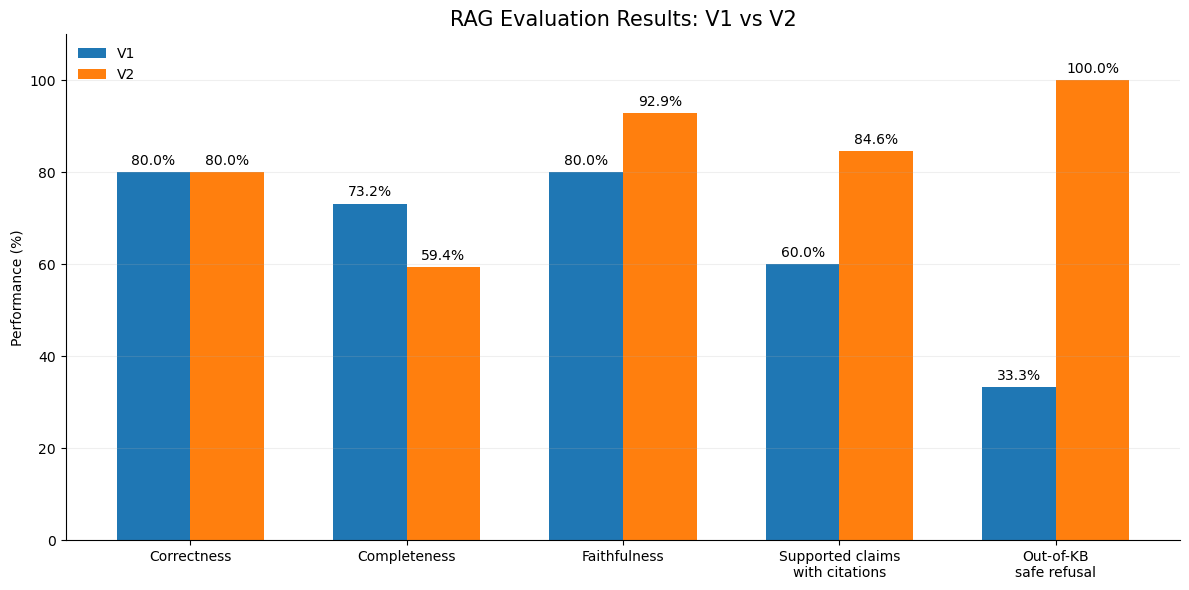

In [57]:
# Visual 1: Main V1 vs V2 evaluation results

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the summary results produced by the separate V1 and V2 notebooks
v1_summary = pd.read_csv(
    EVAL_DIR / "v1_summary_metrics.csv"
)

v2_summary = pd.read_csv(
    EVAL_DIR / "v2_summary_metrics.csv"
)

# Metrics most relevant to the final evaluation
key_metrics = [
    "Answer correctness",
    "Mean question completeness",
    "Claim-level faithfulness",
    "Supported-claim citation coverage",
    "Out-of-KB abstention accuracy"
]

# Pull scores directly from the saved evaluation outputs
v1_scores = (
    v1_summary
    .set_index("metric")
    .loc[key_metrics, "score"]
    .astype(float)
    * 100
)

v2_scores = (
    v2_summary
    .set_index("metric")
    .loc[key_metrics, "score"]
    .astype(float)
    * 100
)

# Shorter labels for the visual
display_labels = [
    "Correctness",
    "Completeness",
    "Faithfulness",
    "Supported claims\nwith citations",
    "Out-of-KB\nsafe refusal"
]

x = np.arange(len(key_metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 6))

bars_v1 = ax.bar(
    x - width / 2,
    v1_scores.values,
    width,
    label="V1"
)

bars_v2 = ax.bar(
    x + width / 2,
    v2_scores.values,
    width,
    label="V2"
)

# Show values directly on the bars
ax.bar_label(
    bars_v1,
    labels=[f"{v:.1f}%" for v in v1_scores],
    padding=3,
    fontsize=10
)

ax.bar_label(
    bars_v2,
    labels=[f"{v:.1f}%" for v in v2_scores],
    padding=3,
    fontsize=10
)

ax.set_title(
    "RAG Evaluation Results: V1 vs V2",
    fontsize=15
)

ax.set_ylabel(
    "Performance (%)"
)

ax.set_xticks(x)
ax.set_xticklabels(display_labels)

ax.set_ylim(0, 110)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

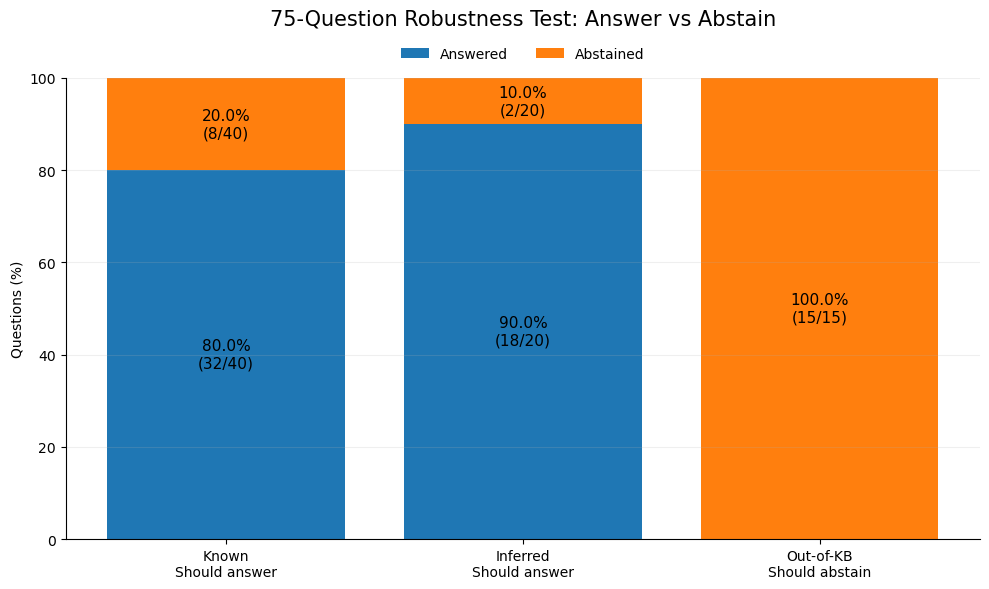

In [60]:
# Visual 2: Answer behaviour across the 75-question robustness test

import matplotlib.pyplot as plt
import numpy as np

question_order = [
    "Known",
    "Inferred",
    "Out-of-KB"
]

# Count answered and abstained questions by type
behaviour_counts = (
    results_df
    .groupby("question_type")["is_abstention"]
    .agg(
        Total="count",
        Abstained="sum"
    )
    .reindex(question_order)
)

behaviour_counts["Answered"] = (
    behaviour_counts["Total"]
    - behaviour_counts["Abstained"]
)

# Convert to percentages
behaviour_counts["Answered_pct"] = (
    behaviour_counts["Answered"]
    / behaviour_counts["Total"]
    * 100
)

behaviour_counts["Abstained_pct"] = (
    behaviour_counts["Abstained"]
    / behaviour_counts["Total"]
    * 100
)

x = np.arange(len(question_order))

fig, ax = plt.subplots(figsize=(10, 6))

# 100% stacked bars
answered_bars = ax.bar(
    x,
    behaviour_counts["Answered_pct"],
    label="Answered"
)

abstained_bars = ax.bar(
    x,
    behaviour_counts["Abstained_pct"],
    bottom=behaviour_counts["Answered_pct"],
    label="Abstained"
)

# Labels inside answered sections
for i, bar in enumerate(answered_bars):
    pct = behaviour_counts.iloc[i]["Answered_pct"]
    count = int(behaviour_counts.iloc[i]["Answered"])
    total = int(behaviour_counts.iloc[i]["Total"])

    if pct > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            pct / 2,
            f"{pct:.1f}%\n({count}/{total})",
            ha="center",
            va="center",
            fontsize=11
        )

# Labels inside abstained sections
for i, bar in enumerate(abstained_bars):
    pct = behaviour_counts.iloc[i]["Abstained_pct"]
    count = int(behaviour_counts.iloc[i]["Abstained"])
    total = int(behaviour_counts.iloc[i]["Total"])
    answered_pct = behaviour_counts.iloc[i]["Answered_pct"]

    if pct > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            answered_pct + pct / 2,
            f"{pct:.1f}%\n({count}/{total})",
            ha="center",
            va="center",
            fontsize=11
        )

ax.set_title(
    "75-Question Robustness Test: Answer vs Abstain",
    fontsize=15,
    pad=38
)

ax.set_ylabel(
    "Questions (%)"
)

ax.set_xticks(x)

ax.set_xticklabels([
    "Known\nShould answer",
    "Inferred\nShould answer",
    "Out-of-KB\nShould abstain"
])

ax.set_ylim(0, 100)

ax.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()